# 07 – Komplexe Zahlen

Komplexe Zahlen spielen in der Nachrichtentechnik eine zentrale Rolle – z. B. im Vorlesungskapitel **02 – Signale und Spektren** (Zeiger, Phasoren, Spektren, Bandpass). Hier lernst du, wie du **komplexe Zahlen in Python** behandelst, wie sich das vom **Programmieren in anderen Sprachen** unterscheidet – und wie du sie **grafisch** darstellst: im **Zeitdiagramm** (Real- und Imaginärteil als zwei Kurven) und in der **komplexen Zahlenebene** (XY-Diagramm) mit Matplotlib.

**Navigation:** [← 06_Plotten](../06_Plotten/06_Plotten.ipynb) | 07_Komplexe_Zahlen | [→ 08_Zufallszahlen](../08_Zufallszahlen/08_Zufallszahlen.ipynb)

## Komplexe Zahlen in Python: eingebauter Typ

In **Python** sind komplexe Zahlen ein **eingebauter Datentyp**. Du schreibst sie mit **`j`** als imaginärer Einheit (nicht `i` wie in der Mathematik): z. B. `3 + 4j` oder `1j`. Python rechnet automatisch mit Real- und Imaginärteil.

**Wichtige Attribute und Funktionen:**
- **`.real`** – Realteil
- **`.imag`** – Imaginärteil
- **`abs(z)`** – Betrag
- **Phase (Winkel):** z. B. mit dem Modul **`cmath`** (`cmath.phase(z)`) oder **NumPy** (`np.angle(z)`).

In [1]:
z = 3 + 4j
print("z =", z)
print("Realteil:", z.real)
print("Imaginaerteil:", z.imag)
print("Betrag:", abs(z))

import cmath
print("Phase (Bogenmass):", cmath.phase(z))

z = (3+4j)
Realteil: 3.0
Imaginaerteil: 4.0
Betrag: 5.0
Phase (Bogenmass): 0.9272952180016122


## Unterschied: Programmieren vs. Mathematik / andere Sprachen

**In der Mathematik** notierst du $z = 3 + 4\mathrm{i}$ und behandelst $\mathrm{i}$ als Symbol. Beim **Programmieren** muss die Sprache festlegen, wie eine komplexe Zahl im Rechner dargestellt wird:

- **Python:** Komplexe Zahlen sind **Bürger erster Klasse** – eigener Typ `complex`, Operatoren `+`, `-`, `*`, `/`, `**` funktionieren direkt. Du musst nichts „nachbauen“. 
- **C / C++:** Es gibt **keinen Standard-Typ** für komplexe Zahlen im Kern der Sprache (C99 hat `_Complex`, wird aber oft nicht genutzt). Typisch: **zwei Variablen** (Real- und Imaginärteil) oder eine **Struktur**; Rechenoperationen schreibst du selbst oder nutzt eine Bibliothek.
- **Vorteil in Python:** Du kannst z. B. Listen oder NumPy-Arrays von komplexen Zahlen bilden und mit Zeigern, Spektren oder Filterkoeffizienten direkt rechnen und plotten.

## Zeitdiagramm: Real- und Imaginärteil als zwei Kurven

Ein **komplexes Signal** $z(t)$ hat für jeden Zeitpunkt $t$ einen Real- und einen Imaginärteil. Du kannst beide **in einem gemeinsamen Plot** über der Zeit darstellen: eine Kurve für $\mathrm{Re}\,z(t)$, eine für $\mathrm{Im}\,z(t)$. So siehst du z. B. den Verlauf einer komplexen Exponentialfunktion (Zeiger).

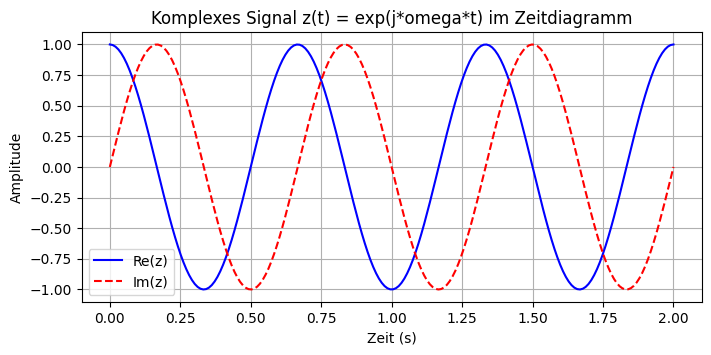

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2, 200)
omega = 2 * np.pi * 1.5   # Kreisfrequenz, 1.5 Hz
z = np.exp(1j * omega * t)  # komplexe Exponentialfunktion e^(j*omega*t)

plt.figure(figsize=(8, 3.5))
plt.plot(t, z.real, label="Re(z)", color="blue")
plt.plot(t, z.imag, label="Im(z)", color="red", linestyle="--")
plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude")
plt.title("Komplexes Signal z(t) = exp(j*omega*t) im Zeitdiagramm")
plt.legend()
plt.grid(True)
plt.show()

## XY-Diagramm: komplexe Zahlenebene

In der **komplexen Zahlenebene** trägst du den **Realteil** auf der **x-Achse** und den **Imaginärteil** auf der **y-Achse** ab. So wird z. B. ein **Zeiger** oder eine **Trajektorie** $z(t)$ sichtbar: Jeder Punkt entspricht einer komplexen Zahl; eine Kurve zeigt, wie sich $z$ mit der Zeit bewegt.

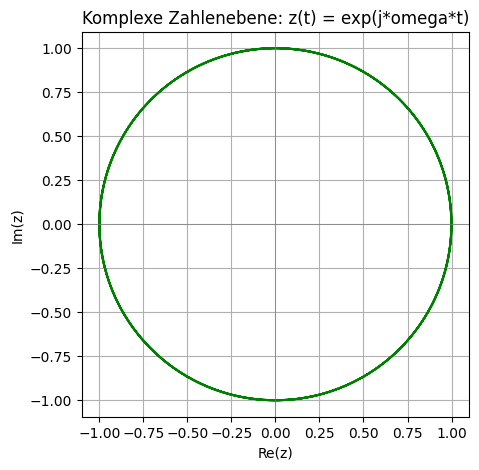

In [3]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2, 200)
omega = 2 * np.pi * 1.5
z = np.exp(1j * omega * t)

plt.figure(figsize=(5, 5))
plt.plot(z.real, z.imag, color="green", linewidth=1.5)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.title("Komplexe Zahlenebene: z(t) = exp(j*omega*t)")
plt.axis("equal")
plt.grid(True)
plt.show()

## Einzelne komplexe Zahlen in der Ebene (Scatter)

Willst du **einzelne komplexe Zahlen** als Punkte darstellen, nutzt du einen **Scatterplot**: x = Realteil, y = Imaginärteil. So kannst du z. B. Zeiger, Polstellen oder Spektralwerte in der komplexen Ebene veranschaulichen.

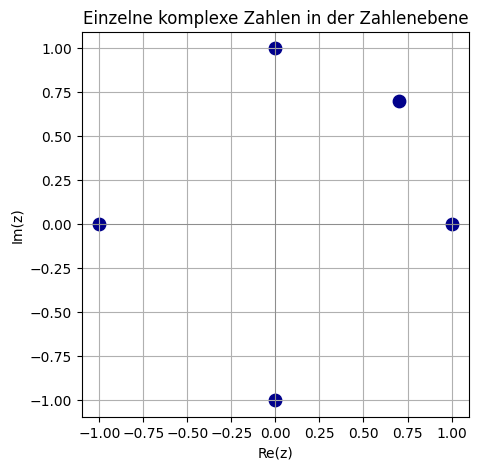

In [4]:
import matplotlib.pyplot as plt

punkte = [1 + 0j, 0 + 1j, -1 + 0j, 0 - 1j, 0.7 + 0.7j]
reals = [z.real for z in punkte]
imags = [z.imag for z in punkte]

plt.figure(figsize=(5, 5))
plt.scatter(reals, imags, s=80, c="darkblue")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.title("Einzelne komplexe Zahlen in der Zahlenebene")
plt.axis("equal")
plt.grid(True)
plt.show()

## Kurz zusammengefasst

| Thema | Inhalt |
|-------|--------|
| **Typ in Python** | `complex`, Schreibweise z. B. `3+4j`; `.real`, `.imag`, `abs(z)`, `cmath.phase(z)`. |
| **Programmieren** | In Python eingebaut; in C oft zwei Variablen oder struct, Operationen selbst oder per Bibliothek. |
| **Zeitdiagramm** | Zwei Kurven in einem Plot: Real- und Imaginärteil über der Zeit (`plt.plot(t, z.real, ...)` und `plt.plot(t, z.imag, ...)`). |
| **Komplexe Ebene** | XY-Diagramm: x = Realteil, y = Imaginärteil; Kurve = Trajektorie, Punkte = einzelne Zahlen (z. B. `plt.scatter`). |

Damit hast du die Grundlage, um Zeiger, Phasoren und spätere Spektraldarstellungen aus dem Kapitel **Signale und Spektren** sowohl zu berechnen als auch mit Matplotlib sichtbar zu machen.

---

**Weiter:** [→ 08_Zufallszahlen](../08_Zufallszahlen/08_Zufallszahlen.ipynb) – Zufallszahlen (`if`/`else`), Schleifen vertiefen.

**Zurück:** [← 06_Plotten](../06_Plotten/06_Plotten.ipynb)